Morganの処理：まずVarianceThresholdで分散ゼロ（QM9では大半が該当するはず）のビットを除去。残ったビットのうち重要度上位を維持しつつ、全体をSVD（もしくはUMAP）で数十次元に圧縮し、圧縮後の特徴量として追加する

In [11]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

SMILES_COL = "smiles"
LABEL_COL = "gap_eV"

df = pd.read_csv("../train/qm9_morgan_fp.csv")
X = df.drop(columns=[SMILES_COL, LABEL_COL])
y = df[LABEL_COL]
print(df.shape)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_scores = []
importances = np.zeros(X.shape[1])

for fold, (train_idx, valid_idx) in enumerate(kf.split(X), start=1):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model = lgb.LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42)
    model.fit(
        X_train, y_train,
        eval_set=[(X_valid, y_valid)],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )

    pred = model.predict(X_valid)
    mae = mean_absolute_error(y_valid, pred)
    fold_scores.append(mae)
    importances += model.feature_importances_ / 5
    print(f"Fold {fold}: MAE = {mae:.4f}")

print(f"\nMorgan CV MAE: {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": importances,
}).sort_values("importance", ascending=False)

importance_df.head(20)
from pathlib import Path

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

importance_df.to_csv(RESULTS_DIR / "morgan_importance.csv", index=False)
print(f"保存しました: {RESULTS_DIR / 'morgan_importance.csv'}")

(106952, 2050)
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.173780 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4096
[LightGBM] [Info] Number of data points in the train set: 85561, number of used features: 2048
[LightGBM] [Info] Start training from score 6.831522
Fold 1: MAE = 0.2915
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.168774 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4096
[LightGBM] [Info] Number of data points in the train set: 85561, number of used features: 2048
[LightGBM] [Info] Start training from score 6.839479
Fold 2: MAE = 0.2960
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.182865 seconds.
You can set `force_row_

重要でない特徴量の除去

In [13]:
import pandas as pd

# 重要度0のビットを特定
importance_df = pd.read_csv("results/morgan_importance.csv")
zero_importance_features = importance_df[importance_df["importance"] == 0]["feature"].tolist()

print(f"重要度0のビット数: {len(zero_importance_features)}")

# Morganの生データから、重要度0のビットを除去
df = pd.read_csv("../train/qm9_morgan_fp.csv")
kept_columns = [c for c in df.columns if c not in zero_importance_features]

df_filtered = df[kept_columns]
df_filtered.to_csv("results/qm9_morgan_fp_filtered.csv", index=False)

print(f"元の列数: {df.shape[1] - 2}")  # smiles, gap_eVを除いた特徴量数
print(f"除去した列数: {len(zero_importance_features)}")
print(f"残った列数: {df_filtered.shape[1] - 2}")

重要度0のビット数: 686
元の列数: 2048
除去した列数: 686
残った列数: 1362


30をそのまま、残りは40次元に圧縮

In [14]:
import pandas as pd
from sklearn.decomposition import TruncatedSVD

SMILES_COL = "smiles"
LABEL_COL = "gap_eV"

TOP_N_KEEP = 30        # そのまま残す重要ビットの数
SVD_N_COMPONENTS = 40  # 残りを圧縮する次元数

# フィルタ済みMorganデータと重要度を読み込む
df = pd.read_csv("results/qm9_morgan_fp_filtered.csv")
importance_df = pd.read_csv("results/morgan_importance.csv")

feature_cols = [c for c in df.columns if c not in [SMILES_COL, LABEL_COL]]

# フィルタ後に残っているビットだけに絞って重要度順に並べる
importance_filtered = importance_df[importance_df["feature"].isin(feature_cols)] \
    .sort_values("importance", ascending=False)

top_features = importance_filtered["feature"].head(TOP_N_KEEP).tolist()
remaining_features = [c for c in feature_cols if c not in top_features]

print(f"そのまま残す重要ビット数: {len(top_features)}")
print(f"SVDで圧縮する残りのビット数: {len(remaining_features)}")

# 残りのビットをSVDで圧縮
svd = TruncatedSVD(n_components=SVD_N_COMPONENTS, random_state=42)
svd_components = svd.fit_transform(df[remaining_features])

svd_df = pd.DataFrame(
    svd_components,
    columns=[f"morgan_svd_{i}" for i in range(SVD_N_COMPONENTS)],
)

print(f"SVD累積寄与率: {svd.explained_variance_ratio_.sum():.4f}")

# 重要ビット(そのまま) + SVD圧縮特徴量 を結合して保存
result_df = pd.concat(
    [df[[SMILES_COL, LABEL_COL]], df[top_features].reset_index(drop=True), svd_df],
    axis=1,
)

result_df.to_csv("results/qm9_morgan_fp_final.csv", index=False)
print(f"保存: results/qm9_morgan_fp_final.csv ({result_df.shape})")

そのまま残す重要ビット数: 30
SVDで圧縮する残りのビット数: 1332
SVD累積寄与率: 0.3128
保存: results/qm9_morgan_fp_final.csv ((106952, 72))


/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:19: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:19: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:19: UserWarning: Glyph 30058 (\N{CJK UNIFIED IDEOGRAPH-756A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:19: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:19: UserWarning: Glyph 23492 (\N{CJK UNIFIED IDEOGRAPH-5BC4}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/q4/lfsm

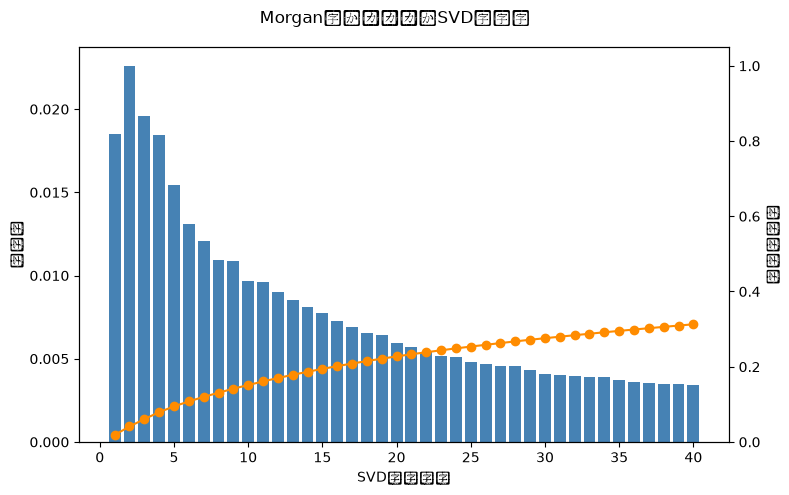

/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:33: UserWarning: Glyph 22311 (\N{CJK UNIFIED IDEOGRAPH-5727}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:33: UserWarning: Glyph 32302 (\N{CJK UNIFIED IDEOGRAPH-7E2E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:33: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:33: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:33: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q4/lfsm

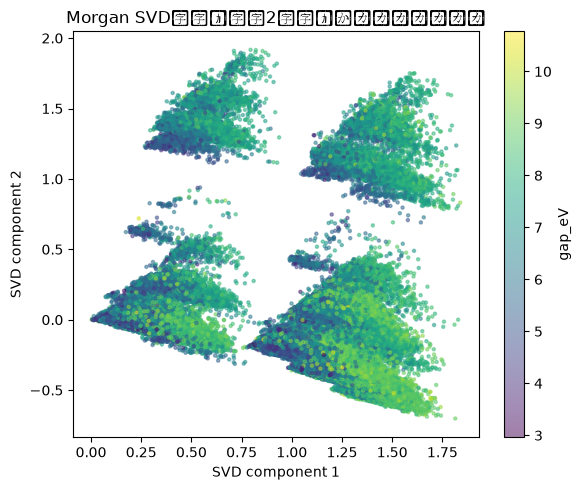

/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:44: UserWarning: Glyph 12381 (\N{HIRAGANA LETTER SO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:44: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:44: UserWarning: Glyph 12414 (\N{HIRAGANA LETTER MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:44: UserWarning: Glyph 27531 (\N{CJK UNIFIED IDEOGRAPH-6B8B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipykernel_50213/2684791844.py:44: UserWarning: Glyph 12375 (\N{HIRAGANA LETTER SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/q4/lfsmj5g15fv1xrzvcd566k640000gp/T/ipy

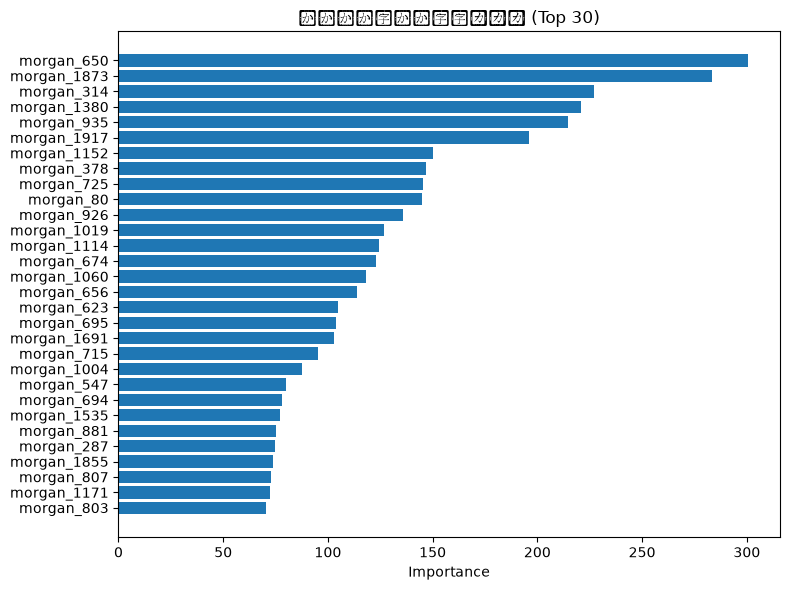

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 1. SVDの寄与率（スクリープロット + 累積寄与率）
explained = svd.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.bar(range(1, len(explained) + 1), explained, color="steelblue", label="各成分の寄与率")
ax1.set_xlabel("SVD成分番号")
ax1.set_ylabel("寄与率")

ax2 = ax1.twinx()
ax2.plot(range(1, len(cumulative) + 1), cumulative, color="darkorange", marker="o", label="累積寄与率")
ax2.set_ylabel("累積寄与率")
ax2.set_ylim(0, 1.05)

fig.suptitle("Morgan残りビットのSVD寄与率")
fig.tight_layout()
plt.savefig("results/morgan_svd_variance.png", dpi=150)
plt.show()

# 2. 上位2成分の散布図（バンドギャップで色分け）
plt.figure(figsize=(6, 5))
sc = plt.scatter(
    svd_df["morgan_svd_0"], svd_df["morgan_svd_1"],
    c=df[LABEL_COL], cmap="viridis", s=5, alpha=0.5,
)
plt.colorbar(sc, label="gap_eV")
plt.xlabel("SVD component 1")
plt.ylabel("SVD component 2")
plt.title("Morgan SVD圧縮（上位2成分）とバンドギャップ")
plt.tight_layout()
plt.savefig("results/morgan_svd_scatter.png", dpi=150)
plt.show()

# 3. そのまま残した重要ビットの重要度バー
plt.figure(figsize=(8, 6))
top_importance = importance_filtered.head(TOP_N_KEEP)
plt.barh(top_importance["feature"], top_importance["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title(f"そのまま残した重要ビット (Top {TOP_N_KEEP})")
plt.tight_layout()
plt.savefig("results/morgan_top_features.png", dpi=150)
plt.show()